In [15]:
import pandas as pd
import numpy as np
from my_ml_package.visualize import plot_digit, plot_cosine_distance, plot_line, plot_data_points
from my_ml_package.distance import euclidean_distance, cosine_distance
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram
# from yellowbrick.cluster import KElbowVisualizer
from sklearn.neighbors import NearestNeighbors
def plot_documents_by_words(documents, max_value=10):
    # draw a 2-d plot to show the distances between A and B, A and C (y axis and x axis are in the same scale)
    plt.figure(figsize=(8, 6))
    plt.scatter(documents[:, 0], documents[:, 1], s=100, c='blue', label='Documents')
    plt.text(documents[0, 0], documents[0, 1], 'A', fontsize=12, ha='right')
    plt.text(documents[1, 0], documents[1, 1], 'B', fontsize=12, ha='right')
    plt.text(documents[2, 0], documents[2, 1], 'C', fontsize=12, ha='right')
    plt.xlim(0, max_value)
    plt.ylim(0, max_value)
    plt.title('Document Word Count Vectors')
    plt.xlabel('Good')
    plt.ylabel('F**k')
    plt.grid()

import warnings
warnings.filterwarnings('ignore')

### 📄 **Document A** (Positive, **good ×10**, **elated ×1**)

> It was a **good** day — really **good**. The sky looked **good**, coffee tasted **good**, and the streets were filled with **good** sounds. Everything just felt **good** — the air, the food, the people. Even her playlist was filled with **good** tracks, humming through a **good** mood. She smiled, not because of something extraordinary, but because everything was *just* right.
> Then came the moment she couldn’t quite name — that lifted her past joy —
> **Elated**, she whispered to herself, surprised by the softness of that feeling.
> Life was simply and overwhelmingly **good**.

✅ **Vector**: `[good=10, fuck=0, elated=1]`

---

### 📄 **Document B** (Frustrated, **good ×7**, **fuck ×2**, **elated ×0**)

> It was supposed to be a **good** morning. He tried — wore his **good** shirt, brewed **good** coffee, even queued a **good** playlist. But the train was late, and his **good** shoes got soaked. Then, his boss replied to his well-prepped email with a one-liner that made no **good** sense. "*What the **fuck*** is wrong with today?" he muttered.
> He walked back out to get some air, tried to stay **good**-tempered, but then a cyclist splashed muddy water all over him.
> "**Fuck** this," he said, giving up on finding a single **good** reason to smile.

✅ **Vector**: `[good=7, fuck=2, elated=0]`

---

### 📄 **Document C** (Poetic and elevated, **good ×1**, **elated ×1**)

> The breeze brushed her face and that alone felt **good**.

> In that quiet moment, she was simply and deeply **elated**.

✅ **Vector**: `[good=1, fuck=0, elated=1]`

---


Distance(A, B): 3.61
Distance(A, C): 9.00


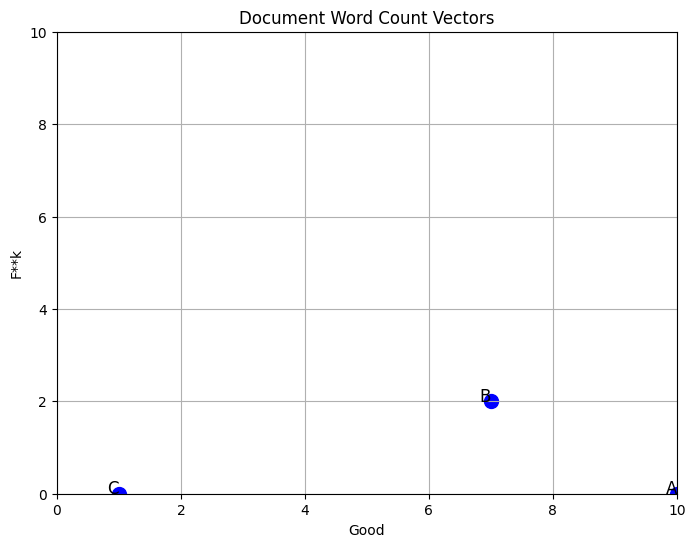

In [17]:


# Define word-count vectors for documents A, B, and C
#                     good  f**k  
documents = np.array([[10,   0,   ],  # A
                      [7,    2,   ],  # B
                      [1,    0,   ]]) # C
plot_documents_by_words(documents, max_value=10)
# Compute Euclidean distances
dist_AB = np.linalg.norm(documents[0] - documents[1])
dist_AC = np.linalg.norm(documents[0] - documents[2])

# Print the results
print(f"Distance(A, B): {dist_AB:.2f}")
print(f"Distance(A, C): {dist_AC:.2f}")



[[1.  0. ]
 [0.7 1. ]
 [0.1 0. ]]
Distance(A, B): 1.04
Distance(A, C): 0.90


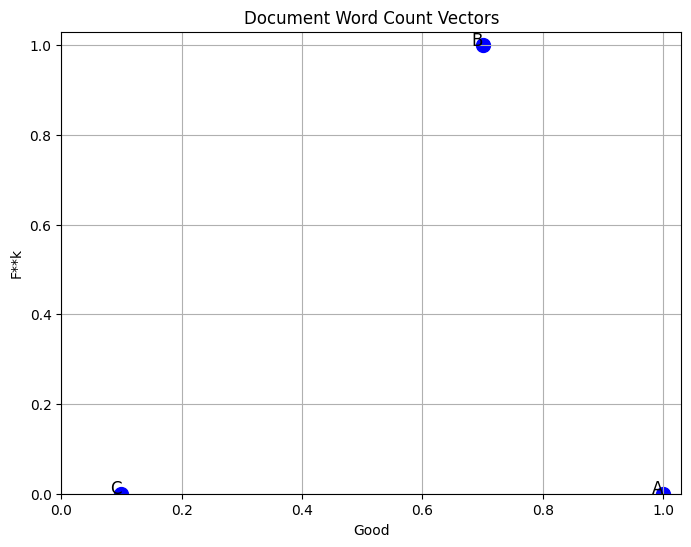

In [22]:
# let's scale each feature (column) to 0 and 1
documents = documents / documents.max(axis=0)
print(documents)

plot_documents_by_words(documents, max_value=1.03)
# Compute Euclidean distances
dist_AB = np.linalg.norm(documents[0] - documents[1])
dist_AC = np.linalg.norm(documents[0] - documents[2])

# Print the results
print(f"Distance(A, B): {dist_AB:.2f}")
print(f"Distance(A, C): {dist_AC:.2f}")



## Distance Metrics

When would we use Distance Metrics?

The most intuitive one
* Euclidean distance: 
    + Generalization: Minkowski distance (Norm 1: Manhattan distance)
    + but can be problematic


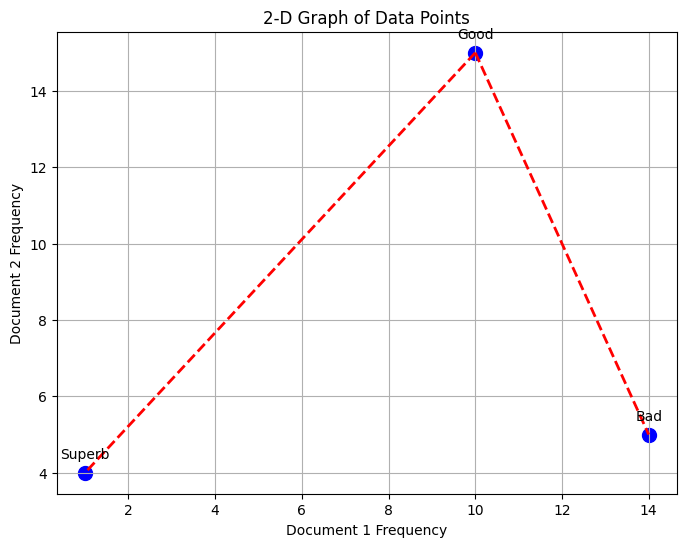

In [57]:

X = np.array([
    # DocA (Negative) DocB (Positive)
    [1,             4],  #   Superb
    [10,             15],  #  Good 
    [14,             5]   #  Bad
])
# Considering that "Good"and "Superb" appear less frequently in negative documents and more frequently in positive ones, 
# can you guess what's the meaning of each column?

fig, ax = plot_data_points(X, labels= ['Superb', 'Good', 'Bad'])
plot_line( ax, X, 1, 0)  # from Good to Superb
plot_line( ax, X, 1, 2)  # from Good to Bad
plt.show()




Problem 1: Does not count relativity between variables
* One possible solution: Cosine Distance
* Others?



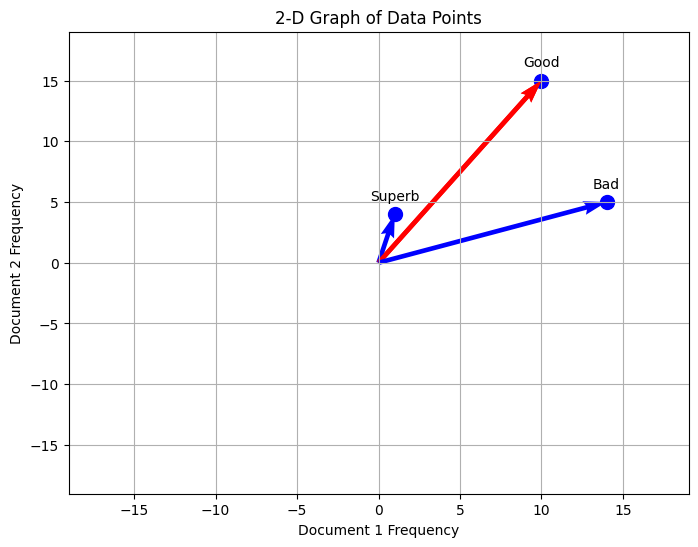

In [47]:
X = np.array([
    [1, 4],  # Superb
    [10, 15],  #  Good
    [14, 5]   # Bad
])

fig, ax = plot_data_points(X, labels= ['Superb', 'Good', 'Bad'])
plot_cosine_distance( ax, X, 1, 0)   # from Good to Superb
plot_cosine_distance( ax, X, 1, 2)  # from Good to Bad
plt.show()

In [49]:
superb = X[0]
good = X[1]
bad = X[2]

def cosine_distance(x, y):
    return 1- np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

print(cosine_distance(good, superb))
print(cosine_distance(good, bad))

0.058258088405162556
0.1977667787259756


How does cosine distance solve this problem MATHEMATICALLY?

In [ ]:
distance_superb_good = None
distance_good_bad = None
print(distance_superb_good) # Superb and Good
print(distance_good_bad) # Good and Bad

Other distance metric:
* Jaccard distance
* Manhattan distance


<!-- To devise a clustering methods, we need to 
* Step 1: define a distance metric between objects $d(x_1, x_2)$
* Step 2: define an objective function (clustering goal)
* Step 3: optimize the objective function by updating parameters -->

When do we need distance metrics?

## K means
The scikit-learn API requies that:
* The data is represented by NumPy array or pandas DataFrame with features in columns and observations in rows.
* The features take on continuous values as opposed to the categories.
* No missing values


In [62]:
# People data with Height cm, Weight kg
X = np.array([
    [175, 75],  # Adult    1
    [60, 5],    # Baby     
    [50, 4],    # Baby     1
    [70, 7],    # Baby     
    [180, 80],  # Adult    1
    [178, 72],  # Adult (new) 1
    [172, 70],  # Adult (new)  
    [169, 74],  # Adult (new)  
    [55, 6],    # Baby (new)  
    [65, 8]     # Baby (new)  1
])

# True labels
y = ['A', 'B', 'B', 'B', 'A', 'A', 'A', 'A', 'B', 'B']
#   [0      1   1    1     0    1    1    1    1    1]



## Generate synthetic dataset with 8 random clusters
model = KMeans(n_clusters=2)
model.fit(X)
y_pred = model.predict(X)

print(y_pred)



[0 1 1 1 0 0 0 0 1 1]


* Steps
  * Initialization 
  * -> Assignment 
  * -> Update <!-- Centroids - Clusters of data points -->
* What are parameters of a K-means model?
* What are hyperparameters of K-means?


In [63]:
import numpy as np
def initialize_centroids(X, k):
    """Randomly initialize k centroids from the dataset X.
    Args:
    X: numpy array of shape (n_samples, n_features), the data.
    k: int, the number of centroids.

    Returns:
    numpy array of shape (k, n_features), the centroids.
    
    """
    indices = np.random.choice(X.shape[0], k, replace=False)
    return X[indices]

def assign_points_to_centroids(X, centroids):
    """Assign each point in X to the nearest centroid."""
    assignments = []
    for point in X:
        distances = np.sqrt(((point - centroids) ** 2).sum(axis=1))
        closest_centroid = np.argmin(distances)
        assignments.append(closest_centroid)
    return np.array(assignments)

def update_centroids(X, assignments, k):
    """Update centroids to be the mean of points assigned to them."""
    new_centroids = np.array([X[assignments == i].mean(axis=0) for i in range(k)])
    return new_centroids

def k_means(X, k, iterations=100):
    """The K-means algorithm."""
    # Step 1: Initialization
    centroids = initialize_centroids(X, k)
    
    for _ in range(iterations):
        # Step 2: Assignment
        assignments = assign_points_to_centroids(X, centroids)
        
        # Step 3: Update
        new_centroids = update_centroids(X, assignments, k)
        
        # Check for convergence (if centroids do not change)
        if np.all(centroids == new_centroids):
            break
        
        centroids = new_centroids
    
    return centroids, _

def predict(X_new, centroids):
    """
    Assign new data points to the nearest centroid.
    
    Parameters:
    - X_new: numpy array of shape (n_samples, n_features), new data points.
    - centroids: numpy array of shape (k, n_features), the centroids.
    
    Returns:
    - assignments: numpy array of shape (n_samples,), cluster indices for each point.
    """
    assignments = []
    for point in X_new:
        distances = np.sqrt(((point - centroids) ** 2).sum(axis=1))
        closest_centroid = np.argmin(distances)
        assignments.append(closest_centroid)
    return np.array(assignments)

In [ ]:
centroids, _ = k_means(X, 2)
predictions = predict(X, centroids)
predictions

array([0, 1, 1, 1, 0, 0, 0, 0, 1, 1])

In [65]:
## Generate synthetic dataset with 8 random clusters
model = KMeans(n_clusters=2)
model.fit(X)
y_pred = model.predict(X)

print(y_pred)

[0 1 1 1 0 0 0 0 1 1]


## K-Mean++: The Importance of Initialization

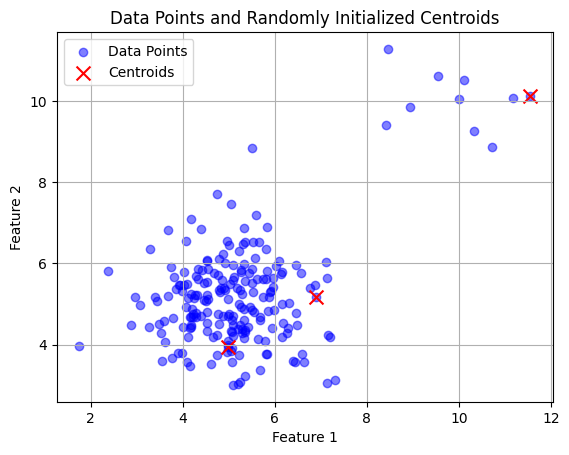

In [67]:
def generate_data_with_dense_cluster(select_centroids_fn, k):
    # Generate a dataset for demonstration if X is not defined
    np.random.seed(42)  # For reproducibility
    dense_cluster = np.random.normal(loc=5, scale=1, size=(200, 2))
    sparse_points = np.random.normal(loc=10, scale=1, size=(10, 2))
    X = np.vstack((dense_cluster, sparse_points))

    # Visualize the centroids along with the data points
    centroids = select_centroids_fn(X, k=k)
    plt.scatter(X[:, 0], X[:, 1], color='blue', alpha=0.5, label='Data Points')
    plt.scatter(centroids[:, 0], centroids[:, 1], color='red', marker='x', s=100, label='Centroids')
    plt.title("Data Points and Randomly Initialized Centroids")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True)
    plt.show()
X = generate_data_with_dense_cluster(select_centroids_fn=initialize_centroids_plusplus, k=3)


In [54]:

def initialize_centroids_plusplus(X, k):
    """Initialize k centroids using the K-means++ algorithm."""
    
    # Step 1: Choose one center uniformly at random from among the data points.
    n_samples, _ = X.shape
    centroids = np.zeros((k, X.shape[1]))
    initial_idx = np.random.choice(n_samples)
    centroids[0] = X[initial_idx]
    
    # Choose the remaining k-1 centers
    for c_id in range(1, k):
        #  Step2: the distance from x to the nearest center
        dist_x_to_c = [np.linalg.norm(X - centroid, axis=1)**2 for centroid in centroids[:c_id]] # shape: (num_c, num_samples)
        distances_to_nc = np.min(dist_x_to_c, axis=0) # shape: (num_samples,)
        # Step 3: Choose one new data point at random as a new center, using a weighted probability distribution 
        # where a point x is chosen with probability proportional to D(x)^2
        probabilities = distances_to_nc / np.sum(distances_to_nc)
        centroid_idx = np.random.choice(n_samples, p=probabilities)
        centroids[c_id] = X[centroid_idx]
    
    return centroids
#         x1, x2, x3, x4, x5, x6, x7, x8, x9, x10
# c1      2   8  ....
        #   2/(100) 8/(100) 
# c2 (x2) 8   0

## Finding K
Let's determine the hyperparameter K assuming that we do not know that $X$ contains features for 2 digits.
* General idea to use the evaluation metrics?
* What is the Elbow plots?
* How to use the Elbow plot?
<!-- The KElbow plot, indeed, is a type of line chart that is used specifically in the context of k-means clustering (and other k-related clustering algorithms) to help determine the optimal number of clusters (denoted as k). The x-axis represents the number of clusters k, while the y-axis represents the value of a specific metric calculated for the clustering model trained with that given k. The "elbow" in the KElbow plot is the point where the plot bends, indicating a diminishing return in the improvement of the metric value with increasing k, suggesting an optimal k value for clustering. -->


In [ ]:
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9]
silhouette_scores = []  
for n_clusters in range_n_clusters:
    model = KMeans(n_clusters=n_clusters, n_init="auto", random_state=10)
    cluster_labels = model.fit_predict(X)
    silhouette_avg = metrics.silhouette_score(X, cluster_labels)
    silhouette_scores.append(silhouette_avg)
plt.plot(range_n_clusters, silhouette_scores, marker='o')


# range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
# from my_ml_package.clustering.metrics import calculate_distortion
# scores_over_k = []  
# for n_clusters in range_n_clusters:
#     model = KMeans(n_clusters=n_clusters, n_init="auto", random_state=10)
#     cluster_labels = model.fit_predict(X)
#     centroids = model.cluster_centers_
#     distortion = calculate_distortion(X.to_numpy(), centroids, cluster_labels)
#     scores_over_k.append(distortion)
# plt.plot(range_n_clusters, scores_over_k, marker='o')


In [ ]:
# How to choose K?
# using KNN to determine n_neighbors
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
# k_range = list(range(1, 21))

# cv_scores = []
# for k in k_range:
#     knn = KNeighborsClassifier(n_neighbors=k)
#     scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
#     cv_scores.append(scores.mean())
#     print("k = %d, accuracy = %0.3f" % (k, scores.mean()))
# # Print the best value of k
# best_k = k_range[cv_scores.index(max(cv_scores))]
# print("Best k: %d" % best_k)
# # Final evaluation
# final_knn = KNeighborsClassifier(n_neighbors=best_k)
# final_knn.fit(X_train, y_train)
# final_score = final_knn.score(X_val, y_val)
# print(final_score)